- H0: 2年後の減少率は1割程度
- H1: 2年後の減少率は1割程度より大きい

In [2]:
import pandas as pd
import numpy as np

from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

#csvファイル読み込み
df = pd.read_csv("./batteries_hours.csv")
#中身を表示してみる
df

/Users/MisayoMacBookPro/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


,new,year2
0,200.614633,181.027960
1,199.716863,164.124190
2,205.733141,171.638352
3,193.768958,174.801830
4,206.248877,198.362352
...,...,...
495,201.674055,179.612115
496,200.392040,176.297149
497,214.773162,175.986271
498,202.211926,197.318569


In [3]:
#はじめの数件だけ表示
df.head()

,new,year2
0,200.614633,181.027960
1,199.716863,164.124190
2,205.733141,171.638352
3,193.768958,174.801830
4,206.248877,198.362352


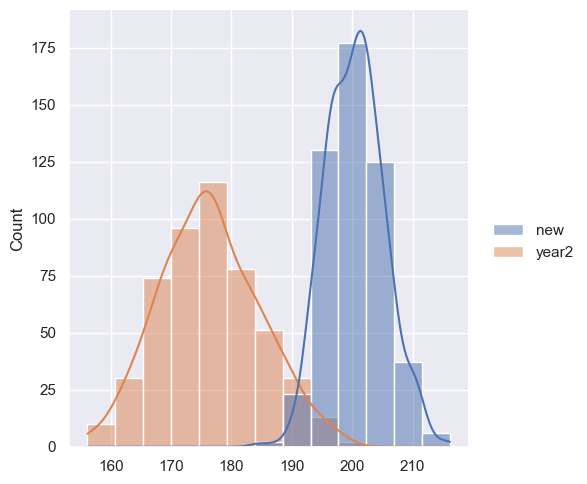

In [4]:
#ヒストグラム
hist_data = pd.DataFrame(columns=['new', 'year2'])
hist_data['new'] = df['new']
hist_data['year2'] = df['year2']
sns.displot(hist_data, kde=True)

<Axes: xlabel='group', ylabel='score'>

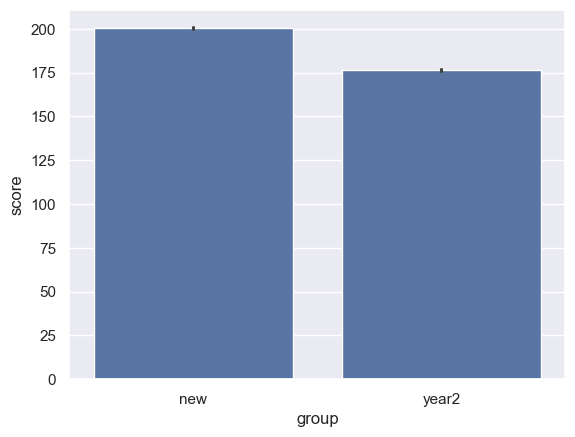

In [5]:
# 棒グラフを描画(平均値の棒グラフ)
df_melted = df.melt(var_name='group', value_name='score')
sns.barplot(data=df_melted, x='group', y='score')

<Axes: xlabel='group', ylabel='score'>

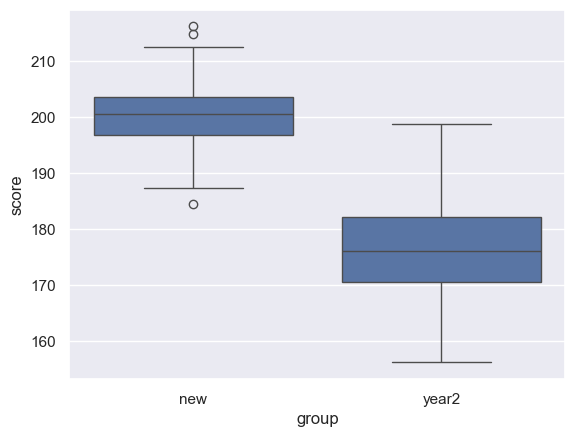

In [6]:
# 箱ひげ図を描画
sns.boxplot(x='group', y='score', data=df_melted)

<Axes: xlabel='group', ylabel='score'>

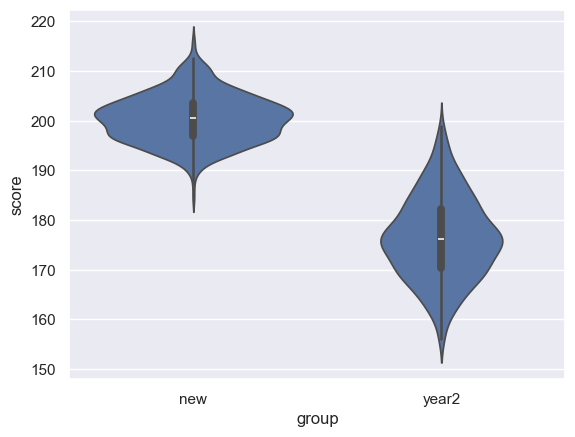

In [7]:
# バイオリンプロットを描画
sns.violinplot(x='group', y='score', data=df_melted)

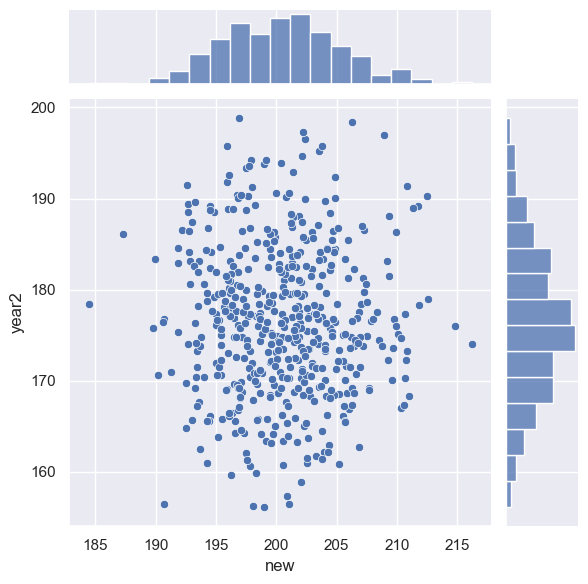

In [8]:
# 散布図を描画
sns.jointplot(x='new', y='year2', data=df)

In [11]:
#母平均の推定値
new_mean = np.mean(df['new'])
print("newの平均： ",new_mean)

year2_mean = np.mean(df['year2'])
print("year2の平均： ",year2_mean)

#自由度
d_of_f = len(df) - 1
print("自由度： ", d_of_f)

# 標準誤差の計算
new_std = np.std(df['new'], ddof=1)
new_se = new_std/np.sqrt(len(df['new']))
print("newの標準誤差： ", new_se)

year2_std = np.std(df['year2'], ddof=1)
year2_se = year2_std/np.sqrt(len(df['year2']))
print("year2の標準誤差： ", year2_se)


newの平均：  200.4746372262155
year2の平均：  176.40215071111032
自由度：  499
newの標準誤差：  0.21442410535224113
year2の標準誤差：  0.37079416461537035


In [16]:
# 95%信頼区間の下限値と上限値を計算
new_interval = stats.t.interval(0.95, d_of_f, loc=new_mean, scale=new_se)
print("newの95%信頼区間の下限値と上限値： ", new_interval)

year2_interval = stats.t.interval(0.95, d_of_f, loc=year2_mean, scale=year2_se)
print("year2の95%信頼区間の下限値と上限値： ", year2_interval)

newの95%信頼区間の下限値と上限値：  (200.0533518842937, 200.89592256813728)
year2の95%信頼区間の下限値と上限値：  (175.6736405178838, 177.13066090433685)


In [17]:
#newとyear2の差を計算
change = df['new'] - df['year2']
change_percent = change / df['new']

change_percent

0      0.097633
1      0.178216
2      0.165723
3      0.097885
4      0.038238
         ...   
495    0.109394
496    0.120239
497    0.180595
498    0.024199
499    0.020878
Length: 500, dtype: float64

In [18]:
change_mean = np.mean(change)
print("変化量： ",change_mean)

change_percent_mean = np.mean(change_percent)
print("変化率： ",change_percent_mean)

変化量：  24.072486515105183
変化率：  0.119564444853397


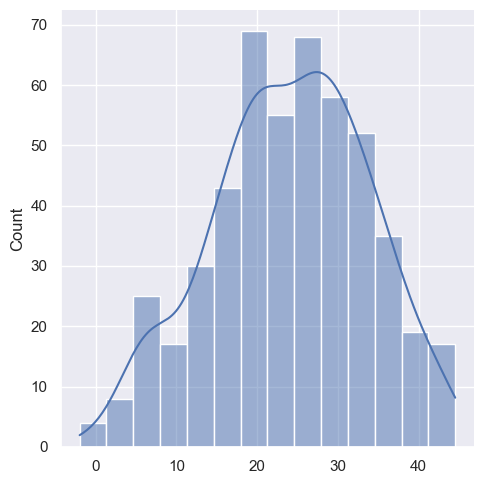

In [19]:
# ヒストグラムを描画
sns.displot(change, kde=True)

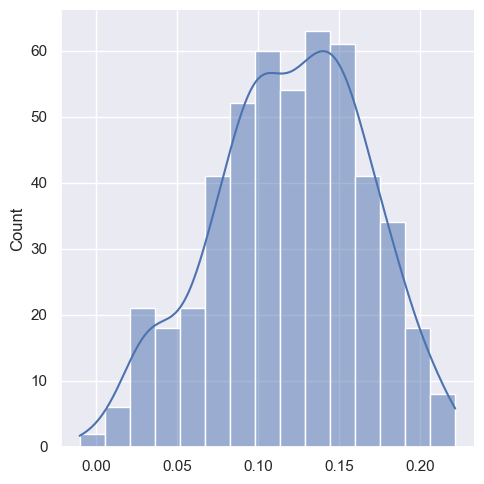

In [20]:
# ヒストグラムを描画
sns.displot(change_percent, kde=True)

<Axes: >

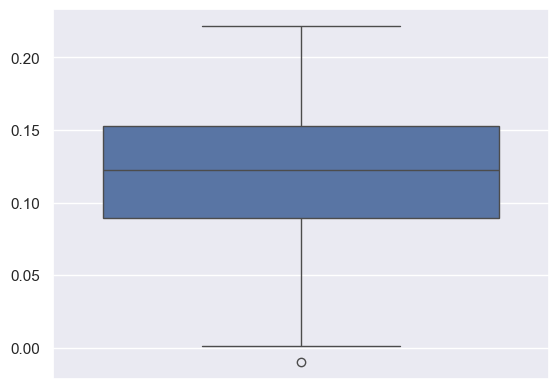

In [38]:
# 箱ひげ図を描画
sns.boxplot(data=change_percent)

<Axes: >

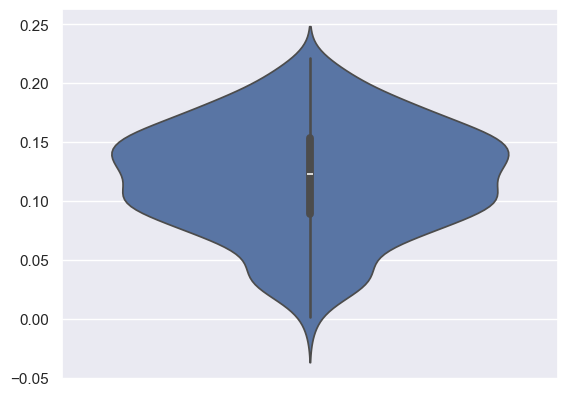

In [37]:
# バイオリンプロットを描画
sns.violinplot(data=change_percent)

In [24]:
# stats.ttest_1samp()を使って片側検定のp値を計算 (H1: 平均 <= 20)
stats.ttest_1samp(change, 20, alternative='less') 


TtestResult(statistic=9.465273816769793, pvalue=1.0, df=499)

In [25]:
# stats.ttest_1samp()を使って片側検定のp値を計算 (H1: 平均 <= 0.1 (10%))
stats.ttest_1samp(change_percent, 0.1, alternative='less') 

TtestResult(statistic=9.363441784706154, pvalue=1.0, df=499)

t値が9.46(変化量)、9.36(変化率)となって1.96をはるかに上回り、p値が両方とも1.0と5%をはるかに上回っているので、H0は棄却となる。